# 06 — Hurdle/Cadence Challenger

The two-stage design addresses two linked prediction tasks:

1. predict whether the customer orders next month;
2. conditional on activity, predict the active-month pattern.

Every feature is known at month *t* and every target is observed at *t+1*. Current lifecycle
package fields, order value, revenue, and company/division assignment are forbidden predictive
features. Whole calendar months define train, calibration, and forward evaluation.

**Notebook structure:** the time-safe model-selection design is followed by untouched
forward-window metrics and calibration plots. The output evaluates historical forecasting.
Confirmed anomaly classification is outside this model's target.


In [1]:
# ruff: noqa: E402
import sys
from pathlib import Path

ROOT = Path('..').resolve()
SRC = ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from module24_workflow import CADENCE_FEATURES, run_hurdle_evaluation

# These are the exact candidate objects and search grid consumed by the workflow below.
logistic_preprocessing = ColumnTransformer(
    [
        (
            'numeric',
            Pipeline(
                [
                    ('impute', SimpleImputer(strategy='median')),
                    ('scale', StandardScaler()),
                ]
            ),
            CADENCE_FEATURES,
        )
    ],
    remainder='drop',
)
activity_models = {
    'logistic': Pipeline(
        [
            ('features', logistic_preprocessing),
            ('model', LogisticRegression(C=0.1, max_iter=1_000, random_state=42)),
        ]
    ),
    'hist_gradient_boosting': Pipeline(
        [
            ('impute', SimpleImputer(strategy='median')),
            (
                'model',
                HistGradientBoostingClassifier(max_iter=180, random_state=42),
            ),
        ]
    ),
}
histogram_grid = {
    'model__learning_rate': [0.05, 0.1, 0.15],
    'model__max_leaf_nodes': [7, 15, 31],
    'model__l2_regularization': [0.5, 1.0, 2.0],
}

metrics, predictions = run_hurdle_evaluation(
    activity_models=activity_models,
    histogram_grid=histogram_grid,
)
print(
    f"Forward predictions: {len(predictions):,} rows; "
    f"selected activity model: {metrics['operational_activity_model']}."
)
display(pd.DataFrame(metrics['calibration_metrics']).round(4))
display(pd.DataFrame(metrics['calibration_check_metrics']).round(4))
display(pd.DataFrame(metrics['forward_metrics']).round(4))
display(pd.DataFrame([metrics['pattern_metrics']]).round(4))
display(
    pd.Series(metrics['forward_direction_counts'], name='rows')
    .rename_axis('direction')
    .to_frame()
)


Forward predictions: 97,627 rows; selected activity model: hist_gradient_boosting_raw.


,model,rows,activity_rate,accuracy,balanced_accuracy,f1,roc_auc,average_precision,log_loss,brier
0,hist_gradient_boosting,45813,0.1315,0.9002,0.6880,0.5131,0.8896,0.6261,0.2495,0.0747
1,logistic,45813,0.1315,0.8972,0.6949,0.5181,0.8788,0.6060,0.2614,0.0779


,model,rows,activity_rate,accuracy,balanced_accuracy,f1,roc_auc,average_precision,log_loss,brier
0,hist_gradient_boosting_raw,15543,0.121,0.9082,0.6913,0.5164,0.8944,0.6257,0.2328,0.069
1,hist_gradient_boosting_isotonic,15543,0.121,0.9078,0.6934,0.5186,0.8942,0.6100,0.2334,0.069


,model,rows,activity_rate,accuracy,balanced_accuracy,f1,roc_auc,average_precision,log_loss,brier
0,hist_gradient_boosting,97627,0.1538,0.8871,0.7063,0.548,0.8874,0.6523,0.2765,0.0839
1,logistic,97627,0.1538,0.8760,0.7241,0.556,0.8759,0.6219,0.2967,0.0912
2,hist_gradient_boosting_raw,97627,0.1538,0.8871,0.7063,0.548,0.8874,0.6523,0.2765,0.0839
3,smoothed_activity_markov,97627,0.1538,0.8462,0.5000,0.000,0.6931,0.3100,0.3767,0.1120
4,global_activity_rate,97627,0.1538,0.8462,0.5000,0.000,0.5000,0.1538,0.4393,0.1332


,rows,classes,accuracy,macro_f1,log_loss,majority_accuracy
0,15016,"[broad, discount_heavy, multi_order, return_he...",0.6021,0.4318,1.0803,0.4863


,rows
direction,
expected,83613
unexpected_activity,8332
unexpected_active_pattern,2989
unexpected_inactivity,2693


## Fitted modeling pipelines

The fitted pipeline evidence below makes preprocessing visible in the notebook. Median imputation
is learned inside each pipeline fit; logistic regression also learns standardization inside the
same pipeline. The tree challenger is intentionally not standardized. This structure keeps each
cross-validation fold's preprocessing estimates confined to that fold's training rows.


In [2]:
best_histogram_params = metrics['grid_search']['best_params']
pipeline_summary = pd.DataFrame(
    [
        {
            'Model': 'Logistic regression',
            'Preprocessing': 'Median imputation + standardization',
            'Selection': 'Fixed C=0.1',
            'Role': 'Linear comparator',
        },
        {
            'Model': 'Histogram gradient boosting',
            'Preprocessing': 'Median imputation; no scaling',
            'Selection': (
                'GridSearchCV winner: '
                f"lr={best_histogram_params['learning_rate']}, "
                f"leaves={best_histogram_params['max_leaf_nodes']}, "
                f"L2={best_histogram_params['l2_regularization']}"
            ),
            'Role': 'Selected nonlinear model',
        },
    ]
)
display(pipeline_summary)


                         Model                            Preprocessing                                      Selection                    Role
0          Logistic regression  Median imputation + standardization                                    Fixed C=0.1       Linear comparator
1  Histogram gradient boosting            Median imputation; no scaling  GridSearchCV winner: lr=0.1, leaves=15, L2=1.0  Selected nonlinear model

## Hyperparameter tuning with chronological cross-validation

The histogram-gradient-boosting challenger is tuned with GridSearchCV over learning rate, maximum
leaf nodes, and L2 regularization. Four expanding-window folds are built only from the training
months: every validation block occurs after its corresponding training block. Calibration and
January-June 2026 forward evaluation remain untouched by the search.

Log loss is the primary selection metric because the workflow needs usable probabilities, not
only a yes/no label; ROC-AUC, average precision, and Brier score are reported alongside it as
ranking and calibration checks.


In [3]:
grid_search = metrics['grid_search']
# Show the complete registered search space before ranking its results.
grid_definition = pd.DataFrame(
    {
        'Hyperparameter': list(grid_search['grid']),
        'Values searched': [
            ', '.join(str(value) for value in values)
            for values in grid_search['grid'].values()
        ],
    }
)
display(grid_definition)

fold_boundaries = pd.DataFrame(grid_search['fold_boundaries']).rename(
    columns={
        'fold': 'Fold',
        'train_start': 'Train start',
        'train_end': 'Train end',
        'validation_start': 'Validation start',
        'validation_end': 'Validation end',
        'train_rows': 'Train rows',
        'validation_rows': 'Validation rows',
    }
)
display(fold_boundaries)

cv_results = pd.DataFrame(grid_search['cv_results']).sort_values('mean_log_loss')
cv_table = pd.DataFrame(
    {
        'Learning rate': cv_results['params'].map(
            lambda params: params['model__learning_rate']
        ),
        'Maximum leaf nodes': cv_results['params'].map(
            lambda params: params['model__max_leaf_nodes']
        ),
        'L2 regularization': cv_results['params'].map(
            lambda params: params['model__l2_regularization']
        ),
        'Mean CV log loss': cv_results['mean_log_loss'],
        'Fold-to-fold standard deviation': cv_results['std_test_score'],
    }
)
print(
    f"Folds: {grid_search['folds']} expanding-window chronological folds; "
    f"best parameters: {grid_search['best_params']}."
)
print(f"Grid-boundary caveat: {grid_search['boundary_note'] or 'None.'}")
display(cv_table.head(10).round(4))


,Hyperparameter,Values searched
0,model__learning_rate,"0.05, 0.1, 0.15"
1,model__max_leaf_nodes,"7, 15, 31"
2,model__l2_regularization,"0.5, 1.0, 2.0"


,Fold,Train start,Train end,Validation start,Validation end,Train rows,Validation rows
0,1,2022-07-01,2023-02-01,2023-03-01,2023-10-01,46458,71886
1,2,2022-07-01,2023-10-01,2023-11-01,2024-06-01,118344,86469
2,3,2022-07-01,2024-06-01,2024-07-01,2025-02-01,204813,100192
3,4,2022-07-01,2025-02-01,2025-03-01,2025-09-01,305005,98571


Folds: 4 expanding-window chronological folds; best parameters: {'l2_regularization': 1.0, 'learning_rate': 0.1, 'max_leaf_nodes': 15}.
Grid-boundary caveat: None.


,Learning rate,Maximum leaf nodes,L2 regularization,Mean CV log loss,Fold-to-fold standard deviation
0,0.10,15,1.0,0.3629,0.0646
1,0.10,7,1.0,0.3634,0.0635
2,0.10,15,0.5,0.3635,0.0655
3,0.05,31,1.0,0.3635,0.0658
4,0.10,15,2.0,0.3635,0.0655
5,0.05,31,0.5,0.3636,0.0659
6,0.05,15,1.0,0.3636,0.0646
7,0.15,7,0.5,0.3636,0.0640
8,0.05,15,2.0,0.3636,0.0647
9,0.05,15,0.5,0.3637,0.0648


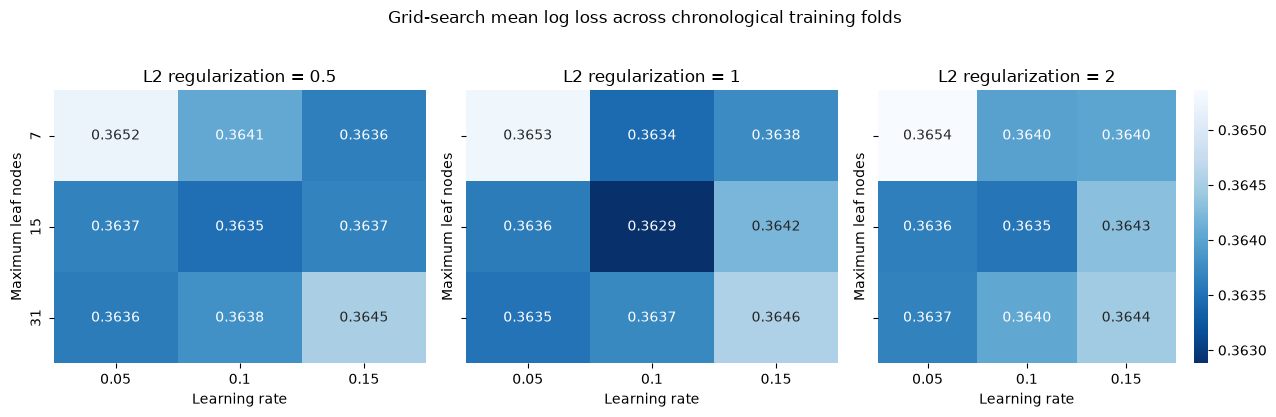

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

heatmap_frame = cv_table.copy()
regularization_values = sorted(heatmap_frame['L2 regularization'].unique())
vmin = heatmap_frame['Mean CV log loss'].min()
vmax = heatmap_frame['Mean CV log loss'].max()
fig, axes = plt.subplots(1, len(regularization_values), figsize=(13, 4), sharey=True)
for ax, regularization in zip(axes, regularization_values, strict=True):
    subset = heatmap_frame.loc[
        heatmap_frame['L2 regularization'].eq(regularization)
    ]
    matrix = subset.pivot(
        index='Maximum leaf nodes',
        columns='Learning rate',
        values='Mean CV log loss',
    )
    # Keep a common color scale so panels remain directly comparable.
    sns.heatmap(
        matrix,
        annot=True,
        fmt='.4f',
        cmap='Blues_r',
        vmin=vmin,
        vmax=vmax,
        cbar=ax is axes[-1],
        ax=ax,
    )
    ax.set_title(f'L2 regularization = {regularization:g}')
    ax.set_xlabel('Learning rate')
axes[0].set_ylabel('Maximum leaf nodes')
fig.suptitle('Grid-search mean log loss across chronological training folds', y=1.03)
plt.tight_layout()
plt.show()


## Final model design

The final design separates next-month activity from the conditional active-month pattern.

Stage 1 is selected by chronological validation and calibration gates against same-target
baselines. Stage 2 supplies conditional context and is evaluated against a majority baseline.
The resulting technical metrics are interpreted only for their stated prediction targets.


## Stage 2 fixed-design scope

Only Stage 1 is grid-searched and calibration-gated. The conditional active-pattern classifier
uses the fixed configuration shown below and is compared with a majority baseline on the untouched
forward window. It is exploratory context for active months, not a separately optimized model.


In [5]:
pattern_design = metrics['pattern_model_design']
display(pd.DataFrame([pattern_design['fixed_params']]))
print(f"Selection approach: {pattern_design['selection']}")
print(pattern_design['rationale'])


,learning_rate,max_iter,max_leaf_nodes,l2_regularization
0,0.06,180,31,1.0


Selection approach: fixed_not_grid_searched
Stage 2 is exploratory active-month context. Its fixed configuration is evaluated on the untouched forward window against a majority baseline rather than presented as a separately optimized classifier.


## Interpreting the logistic comparator

The selected operational model is tree-based, so the logistic comparator supplies the
comparison of feature associations. Because its inputs are standardized inside each fitted pipeline,
the coefficients below compare one-standard-deviation changes. They describe model associations,
with interpretation limited to the logistic comparator rather than the selected tree model.


,Feature,Standardized coefficient,Odds ratio per standard deviation,Direction
0,Average orders — last 3 months,3.226,25.190,Higher probability
1,Average orders — last 6 months,2.044,7.722,Higher probability
2,Activity rate — last 12 months,1.162,3.195,Higher probability
3,Orders this month,0.877,2.404,Higher probability
4,Activity rate — last 6 months,-0.571,0.565,Lower probability
5,Current inactive streak,-0.414,0.661,Lower probability
6,Months since last activity,-0.414,0.661,Lower probability
7,Active order days this month,0.391,1.479,Higher probability
8,Observed tenure as of this month,0.344,1.411,Higher probability
9,Active in the same month last year,0.220,1.246,Higher probability


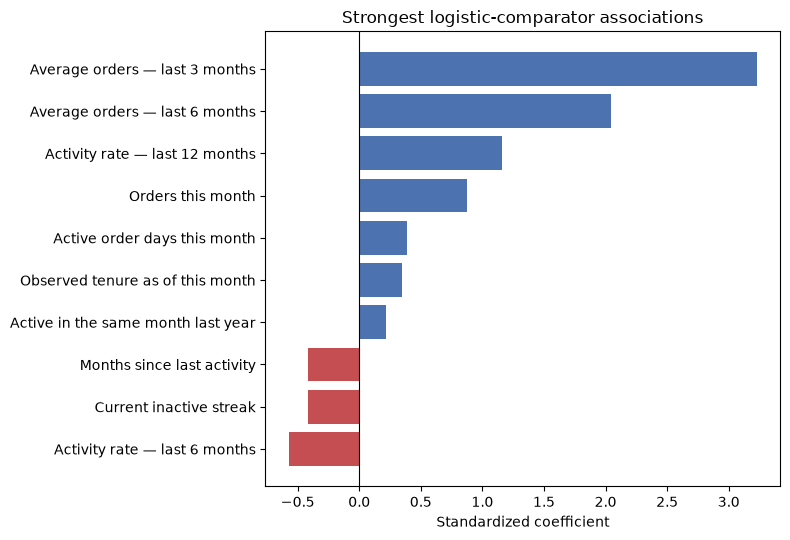

In [6]:
feature_labels = {
    'current_has_order': 'Order placed this month',
    'active_rate_3m': 'Activity rate — last 3 months',
    'active_rate_6m': 'Activity rate — last 6 months',
    'active_rate_12m': 'Activity rate — last 12 months',
    'order_count_mean_3m': 'Average orders — last 3 months',
    'order_count_mean_6m': 'Average orders — last 6 months',
    'order_count_mean_12m': 'Average orders — last 12 months',
    'order_count_sd_12m': 'Order-count variability — last 12 months',
    'months_since_active': 'Months since last activity',
    'inactive_streak': 'Current inactive streak',
    'same_month_last_year_active': 'Active in the same month last year',
    'same_month_last_year_available': 'Prior-year month is available',
    'current_order_count': 'Orders this month',
    'current_active_order_days': 'Active order days this month',
    'current_distinct_product_count': 'Distinct products this month',
    'current_discount_rate': 'Discount-line rate this month',
    'current_promo_line_share': 'Promotion-line share this month',
    'current_return_line_rate': 'Return-line rate this month',
    'current_top_product_share': 'Top-product concentration this month',
    'tenure_months_asof': 'Observed tenure as of this month',
    'calendar_month_sin': 'Seasonal calendar phase — sine',
    'calendar_month_cos': 'Seasonal calendar phase — cosine',
}
coefficient_frame = pd.DataFrame(
    metrics['logistic_coefficient_interpretation']['coefficients']
).head(10)
# Translate engineered feature names into reviewer-friendly labels.
coefficient_frame['Feature'] = coefficient_frame['feature'].map(feature_labels)
coefficient_frame['Direction'] = coefficient_frame['association_direction'].map(
    {
        'higher next-month order probability': 'Higher probability',
        'lower next-month order probability': 'Lower probability',
    }
)
display(
    coefficient_frame[
        ['Feature', 'standardized_coefficient', 'odds_ratio_per_sd', 'Direction']
    ]
    .rename(
        columns={
            'standardized_coefficient': 'Standardized coefficient',
            'odds_ratio_per_sd': 'Odds ratio per standard deviation',
        }
    )
    .round(3)
)

plot_coefficients = coefficient_frame.sort_values('standardized_coefficient')
colors = plot_coefficients['standardized_coefficient'].map(
    lambda value: '#4C72B0' if value > 0 else '#C44E52'
)
fig, ax = plt.subplots(figsize=(8, 5.5))
ax.barh(
    plot_coefficients['Feature'],
    plot_coefficients['standardized_coefficient'],
    color=colors,
)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Strongest logistic-comparator associations')
ax.set_xlabel('Standardized coefficient')
ax.set_ylabel('')
plt.tight_layout()
plt.show()


**Interpretation.** Recent order-frequency averages have the strongest positive
logistic associations, while longer inactivity is associated with a lower next-month order
probability. These correlated behavioral features are useful direction checks, not causal effects
and not explanations of the selected tree model.


## Forward-window visual diagnostics

The following plots keep metrics with opposite directions in separate panels, then show the ROC
curve, predicted-probability distribution, December calibration reliability, active-pattern
confusion matrix, and expectation-result mix.


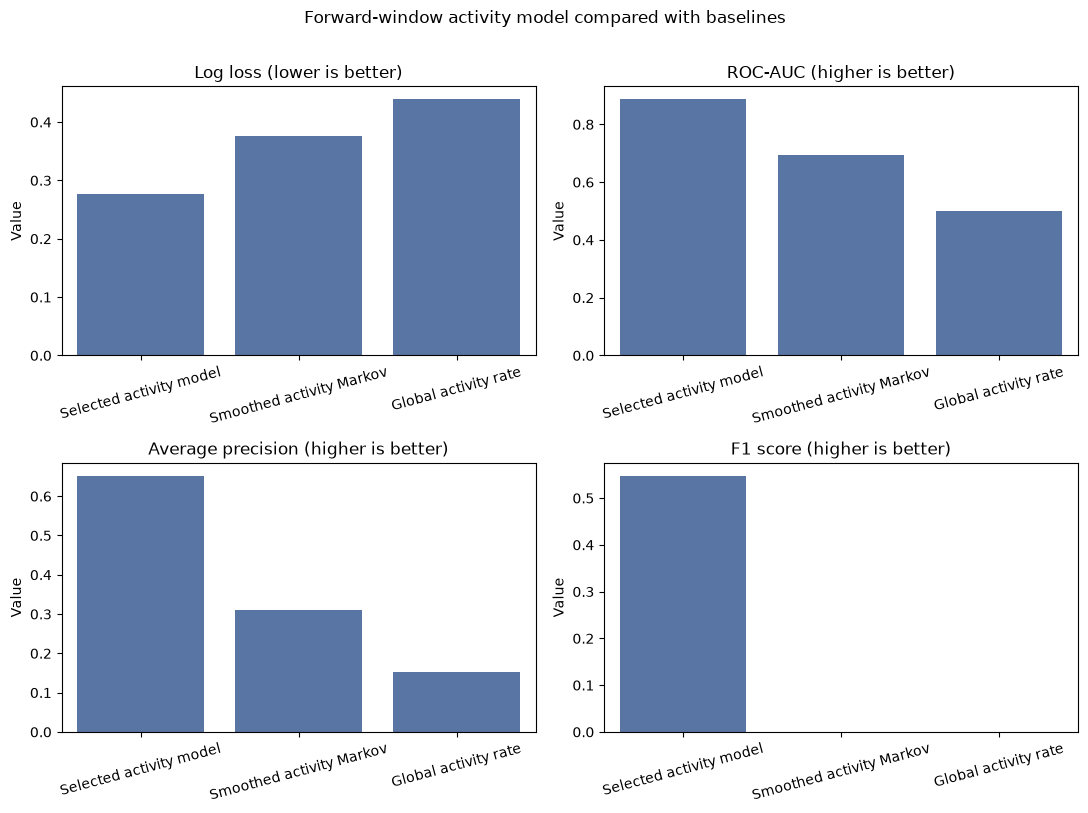

In [7]:
model_labels = {
    metrics['operational_activity_model']: 'Selected activity model',
    'smoothed_activity_markov': 'Smoothed activity Markov',
    'global_activity_rate': 'Global activity rate',
}
forward = pd.DataFrame(metrics['forward_metrics'])
# Keep the selected model and two same-target baselines in the main comparison.
plot_models = forward.loc[forward['model'].isin(model_labels)].copy()
plot_models['Model'] = plot_models['model'].map(model_labels)
metric_specs = [
    ('log_loss', 'Log loss (lower is better)'),
    ('roc_auc', 'ROC-AUC (higher is better)'),
    ('average_precision', 'Average precision (higher is better)'),
    ('f1', 'F1 score (higher is better)'),
]
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, (metric, title) in zip(axes.flat, metric_specs, strict=True):
    sns.barplot(data=plot_models, x='Model', y=metric, ax=ax, color='#4C72B0')
    ax.set_title(title)
    ax.set_xlabel('')
    ax.set_ylabel('Value')
    ax.tick_params(axis='x', rotation=15)
fig.suptitle('Forward-window activity model compared with baselines', y=1.01)
plt.tight_layout()
plt.show()


**Interpretation.** On the untouched forward window, the selected activity
model improves probability quality and ranking over the same-target Markov and global-rate
baselines. The comparison supports the forecasting component. Anomaly correctness and business
usefulness are evaluated separately.


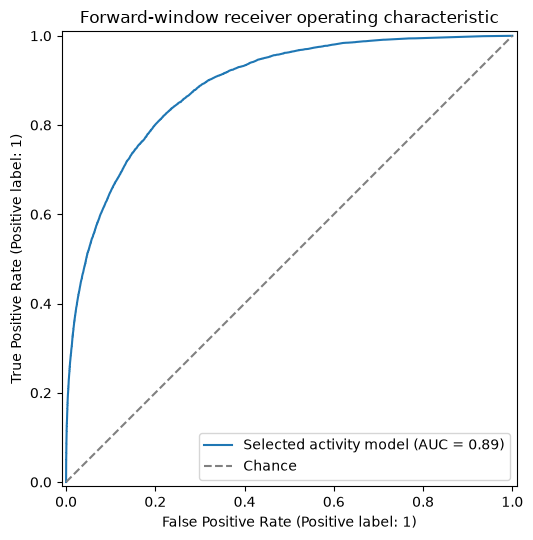

In [8]:
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

fig, ax = plt.subplots(figsize=(5.5, 5.5))
RocCurveDisplay.from_predictions(
    predictions['next_has_order'],
    predictions['p_next_order'],
    name='Selected activity model',
    ax=ax,
)
# Add chance performance as a visual reference.
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Chance')
ax.set_title('Forward-window receiver operating characteristic')
ax.legend()
plt.tight_layout()
plt.show()


**Interpretation.** The ROC curve remains well above the chance diagonal, so
the model ranks active months ahead of inactive months across thresholds. ROC-AUC measures ranking
separation. Calibration and operating-threshold selection require their corresponding
diagnostics.


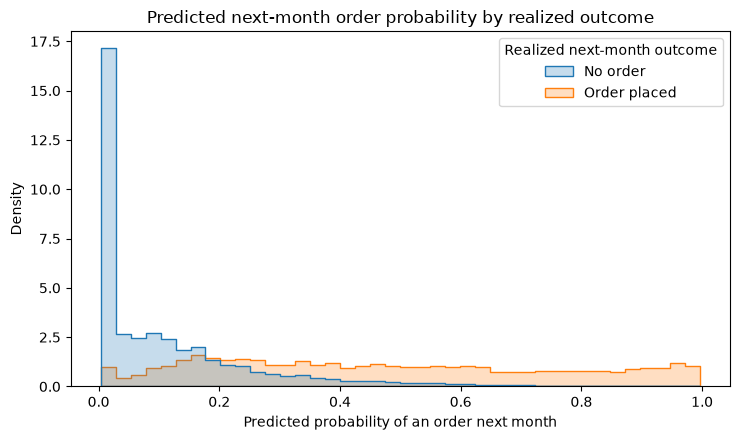

In [9]:
plot_frame = predictions.assign(
    **{
        'Realized next-month outcome': predictions['next_has_order'].map(
            {0: 'No order', 1: 'Order placed'}
        )
    }
)
fig, ax = plt.subplots(figsize=(7.5, 4.5))
sns.histplot(
    data=plot_frame,
    x='p_next_order',
    hue='Realized next-month outcome',
    bins=40,
    stat='density',
    common_norm=False,
    element='step',
    ax=ax,
)
ax.set_title('Predicted next-month order probability by realized outcome')
ax.set_xlabel('Predicted probability of an order next month')
ax.set_ylabel('Density')
plt.tight_layout()
plt.show()


**Interpretation.** Realized order months receive higher predicted
probabilities on average, but the distributions overlap. That overlap explains why a fixed
classification threshold produces both missed orders and false activity predictions and why the
workflow uses a capacity-bounded review queue rather than an automatic decision.


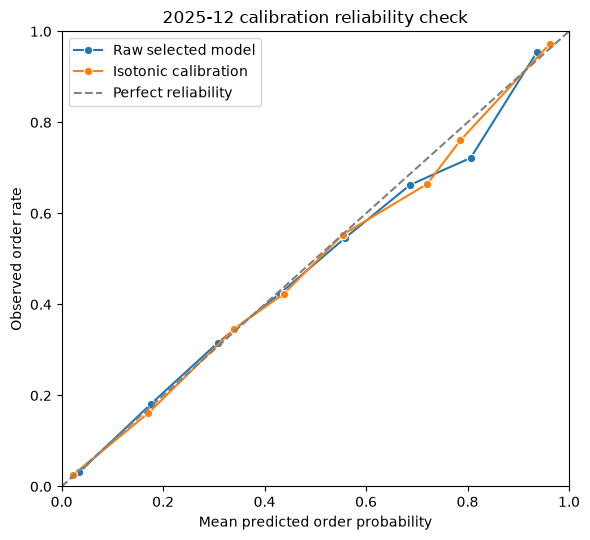

In [10]:
reliability_evidence = metrics['calibration_reliability']
reliability = pd.DataFrame(reliability_evidence['rows'])
reliability['Probability variant'] = reliability['model'].map(
    lambda name: 'Isotonic calibration' if name.endswith('_isotonic') else 'Raw selected model'
)
fig, ax = plt.subplots(figsize=(6, 5.5))
sns.lineplot(
    data=reliability,
    x='mean_predicted_probability',
    y='observed_activity_rate',
    hue='Probability variant',
    marker='o',
    ax=ax,
)
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect reliability')
ax.set_title(f"{reliability_evidence['target_month']} calibration reliability check")
ax.set_xlabel('Mean predicted order probability')
ax.set_ylabel('Observed order rate')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()


**Interpretation.** Both curves are close to the perfect-reliability diagonal,
but the isotonic variant does not improve the pre-registered December log-loss and Brier gate.
The workflow therefore retains the raw model; visual closeness alone is not used to select
calibration.


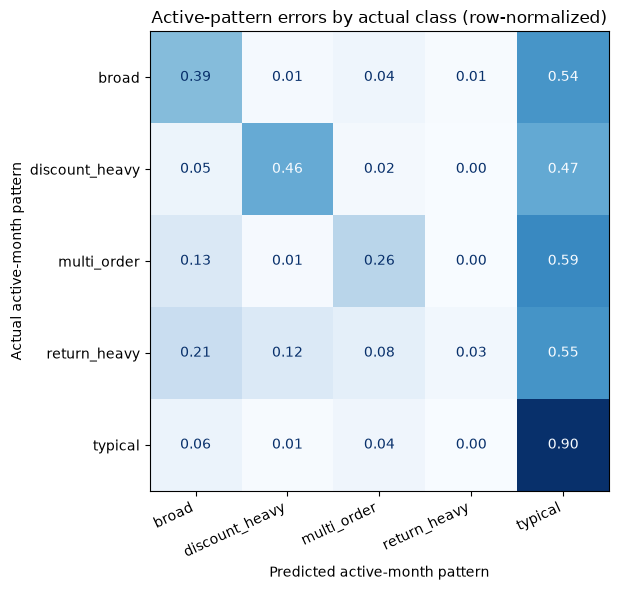

In [11]:
active_patterns = predictions.loc[predictions['next_has_order'].eq(1)]
pattern_labels = metrics['pattern_metrics']['classes']
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(
    active_patterns['actual_active_pattern'],
    active_patterns['predicted_active_pattern'],
    labels=pattern_labels,
    normalize='true',
    values_format='.2f',
    cmap='Blues',
    colorbar=False,
    ax=ax,
)
ax.set_title('Active-pattern errors by actual class (row-normalized)')
ax.set_xlabel('Predicted active-month pattern')
ax.set_ylabel('Actual active-month pattern')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()


**Interpretation.** Stage 2 recognizes the common `typical` pattern much more
reliably than the minority patterns, which are frequently predicted as typical. Its macro-F1 is
therefore materially below its overall accuracy. This fixed-design stage is exploratory context
for active months, not a separately optimized production classifier.


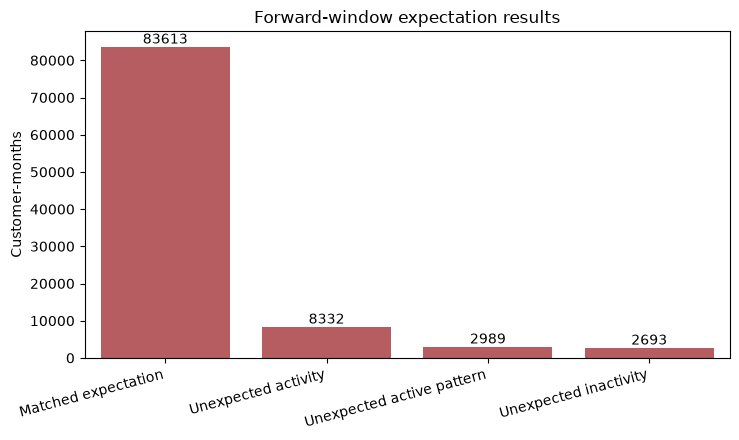

In [12]:
direction_labels = {
    'expected': 'Matched expectation',
    'unexpected_inactivity': 'Unexpected inactivity',
    'unexpected_activity': 'Unexpected activity',
    'unexpected_active_pattern': 'Unexpected active pattern',
}
direction_counts = (
    pd.Series(metrics['forward_direction_counts'], name='Customer-months')
    .rename_axis('direction')
    .reset_index()
)
direction_counts['Expectation result'] = direction_counts['direction'].map(direction_labels)
fig, ax = plt.subplots(figsize=(7.5, 4.5))
sns.barplot(
    data=direction_counts,
    x='Expectation result',
    y='Customer-months',
    ax=ax,
    color='#C44E52',
)
ax.set_title('Forward-window expectation results')
ax.set_xlabel('')
ax.set_ylabel('Customer-months')
for container in ax.containers:
    ax.bar_label(container)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()


**Interpretation.** Most forward customer-months match the model's
expectation; unexpected activity, inactivity, and active patterns form much smaller candidate
pools. Operational review still selects an exact monthly capacity from those pools instead of
treating every expectation mismatch as equally important.


In [13]:
probability_summary = (
    predictions.assign(
        **{'Expectation result': predictions['hurdle_direction'].map(direction_labels)}
    )
    .groupby('Expectation result')['p_next_order']
    .describe()
    .round(4)
)
display(probability_summary)


,count,mean,std,min,25%,50%,75%,max
Expectation result,,,,,,,,
Matched expectation,83613.0,0.1267,0.1781,0.0033,0.0085,0.0605,0.1676,0.9961
Unexpected active pattern,2989.0,0.7357,0.1431,0.5001,0.6107,0.7279,0.8615,0.9965
Unexpected activity,8332.0,0.2598,0.1330,0.0033,0.1565,0.2531,0.3715,0.5000
Unexpected inactivity,2693.0,0.6354,0.1122,0.5002,0.5468,0.6047,0.6996,0.9886


## Customer-clustered uncertainty for forward improvements

The fixed January--June 2026 holdout is resampled by customer (not individual rows), keeping
all sampled forward months together. This respects repeated observations within a customer.
Negative log-loss differences and positive ROC-AUC differences favor the selected model.


In [14]:
# Read the current aggregate sidecar from the aggregate evidence sidecar.
# This cell is deliberately executable on its own and never exposes customer-level data.
import json
import sys
from pathlib import Path

SRC = Path('..').resolve() / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import pandas as pd

from module24_workflow import OUTPUT_CACHE

sidecar_metrics = json.loads((OUTPUT_CACHE / '06_hurdle_metrics.json').read_text())
uncertainty_rows = []
for comparison in sidecar_metrics['forward_uncertainty']:
    differences = comparison['selected_minus_baseline']
    uncertainty_rows.append({
        'Baseline': comparison['baseline'],
        'Log-loss difference': differences['log_loss']['point_difference'],
        'Log-loss 95% CI': str([round(value, 4) for value in differences['log_loss']['ci_95']]),
        'ROC-AUC difference': differences['roc_auc']['point_difference'],
        'ROC-AUC 95% CI': str([round(value, 4) for value in differences['roc_auc']['ci_95']]),
    })
uncertainty = pd.DataFrame(uncertainty_rows)
display(uncertainty.round(4))
print(
    f"Method: {sidecar_metrics['forward_uncertainty'][0]['method']}; "
    f"{sidecar_metrics['forward_uncertainty'][0]['resamples']:,} resamples; "
    f"seed {sidecar_metrics['forward_uncertainty'][0]['random_state']}."
)


,Baseline,Log-loss difference,Log-loss 95% CI,ROC-AUC difference,ROC-AUC 95% CI
0,smoothed_activity_markov,-0.1002,"[-0.1028, -0.0975]",0.1943,"[0.1898, 0.1982]"
1,global_activity_rate,-0.1628,"[-0.1672, -0.1586]",0.3874,"[0.3837, 0.391]"


Method: customer_clustered_nonparametric_bootstrap; 1,000 resamples; seed 42.


**Interpretation.** The intervals quantify sampling uncertainty for the historical forward
holdout. Anomaly correctness, actionability, adoption, ROI, and future financial performance
remain outside this statistical evaluation.


## Interpretation

Activity metrics test a real next-month prediction. Pattern metrics are conditional on an order
occurring. The anomaly queue is created only after the realized month is observed, by ranking
expectation violations. Novelty and actionability are measured in the commercial review.
